<a href="https://colab.research.google.com/github/lcribeiro1976/Intelig-nciaArtificial/blob/main/atividade_3/atividade_3_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
!pip install shap -q

In [50]:
df = pd.read_csv('titanic.csv')

In [51]:
from google.colab import files
uploaded = files.upload()  # faz upload do titanic.csv
df = pd.read_csv('titanic.csv')

Saving titanic.csv to titanic (3).csv


In [52]:
# 1 - COLETA E CARREGAMENTO DOS DADOS

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)


In [54]:
# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

# Carregar dataset
df = pd.read_csv('titanic.csv') # Changed 'csv_file' to 'titanic.csv'

print('Shape:', df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [55]:
# Tipos de dados
print('=== Tipos de Dados ===')
print(df.dtypes)
print()

# Valores ausentes
print('=== Valores Ausentes ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Ausentes': missing, '% Ausente': missing_pct})[missing > 0])

=== Tipos de Dados ===
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

=== Valores Ausentes ===
          Ausentes  % Ausente
Age            177      19.87
Cabin          687      77.10
Embarked         2       0.22


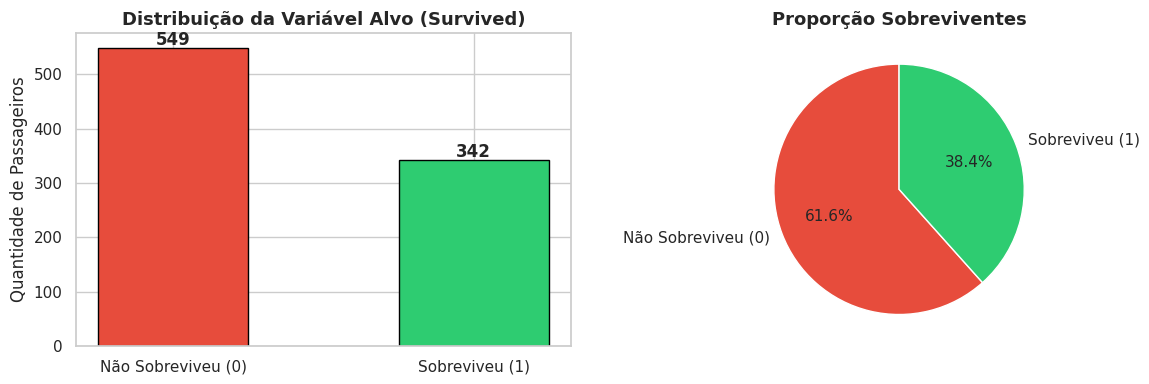

Total: 891 passageiros | Sobreviveram: 342 (38.4%) | Não sobreviveram: 549 (61.6%)


In [56]:
# Distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Survived'].value_counts()
labels = ['Não Sobreviveu (0)', 'Sobreviveu (1)']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribuição da Variável Alvo (Survived)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade de Passageiros')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporção Sobreviventes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribuicao_alvo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total: {len(df)} passageiros | Sobreviveram: {counts[1]} ({counts[1]/len(df)*100:.1f}%) | Não sobreviveram: {counts[0]} ({counts[0]/len(df)*100:.1f}%)')

In [57]:
# 2 - PREPARAÇÃO DOS DADOS

In [58]:
df_prep = df.copy()

# --- Tratamento de valores ausentes ---
# Age: preencher com mediana
df_prep['Age'].fillna(df_prep['Age'].median(), inplace=True)

# Embarked: preencher com moda
df_prep['Embarked'].fillna(df_prep['Embarked'].mode()[0], inplace=True)

# Cabin: muitas ausências — criar flag binária
df_prep['HasCabin'] = df_prep['Cabin'].notnull().astype(int)

# --- Engenharia de features ---
# FamilySize
df_prep['FamilySize'] = df_prep['SibSp'] + df_prep['Parch'] + 1
df_prep['IsAlone'] = (df_prep['FamilySize'] == 1).astype(int)

# --- Transformação de categóricas ---
df_prep['Sex'] = df_prep['Sex'].map({'male': 0, 'female': 1})
df_prep['Embarked'] = df_prep['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# --- Seleção de features ---
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
            'Embarked', 'HasCabin', 'FamilySize', 'IsAlone']

X = df_prep[features]
y = df_prep['Survived']

# --- Divisão treino/teste ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Features utilizadas: {features}')
print()
print('Valores ausentes após tratamento:')
print(X.isnull().sum())

Treino: 712 amostras | Teste: 179 amostras
Features utilizadas: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'HasCabin', 'FamilySize', 'IsAlone']

Valores ausentes após tratamento:
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
HasCabin      0
FamilySize    0
IsAlone       0
dtype: int64


In [59]:
# 3 - TREINAMENTO DO MODELO

In [60]:
# Criar e treinar o RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print('Modelo RandomForestClassifier treinado com sucesso!')
print(f'  n_estimators : {rf_model.n_estimators}')
print(f'  max_depth    : {rf_model.max_depth}')
print(f'  Features     : {list(X.columns)}')

Modelo RandomForestClassifier treinado com sucesso!
  n_estimators : 200
  max_depth    : 8
  Features     : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'HasCabin', 'FamilySize', 'IsAlone']


In [61]:
# 4 - VALIDAÇÃO DO MODELO

In [62]:
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Acurácia: {acc:.4f} ({acc*100:.2f}%)')
print()
print('=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred,
      target_names=['Não Sobreviveu', 'Sobreviveu']))

Acurácia: 0.7765 (77.65%)

=== Relatório de Classificação ===
                precision    recall  f1-score   support

Não Sobreviveu       0.80      0.85      0.82       110
    Sobreviveu       0.74      0.65      0.69        69

      accuracy                           0.78       179
     macro avg       0.77      0.75      0.76       179
  weighted avg       0.77      0.78      0.77       179



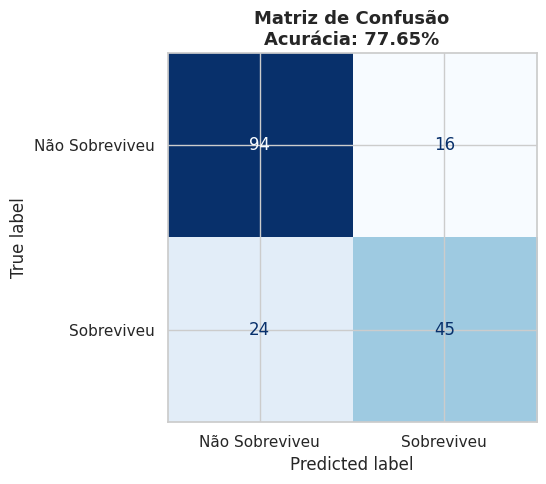

Verdadeiros Negativos (TN): 94  |  Falsos Positivos (FP): 16
Falsos Negativos    (FN): 24  |  Verdadeiros Positivos (TP): 45


In [63]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Não Sobreviveu', 'Sobreviveu'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusão\nAcurácia: {acc*100:.2f}%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdadeiros Negativos (TN): {tn}  |  Falsos Positivos (FP): {fp}')
print(f'Falsos Negativos    (FN): {fn}  |  Verdadeiros Positivos (TP): {tp}')

In [64]:
# 5 - ANÁLISE DE FEATURE IMPORTANCE

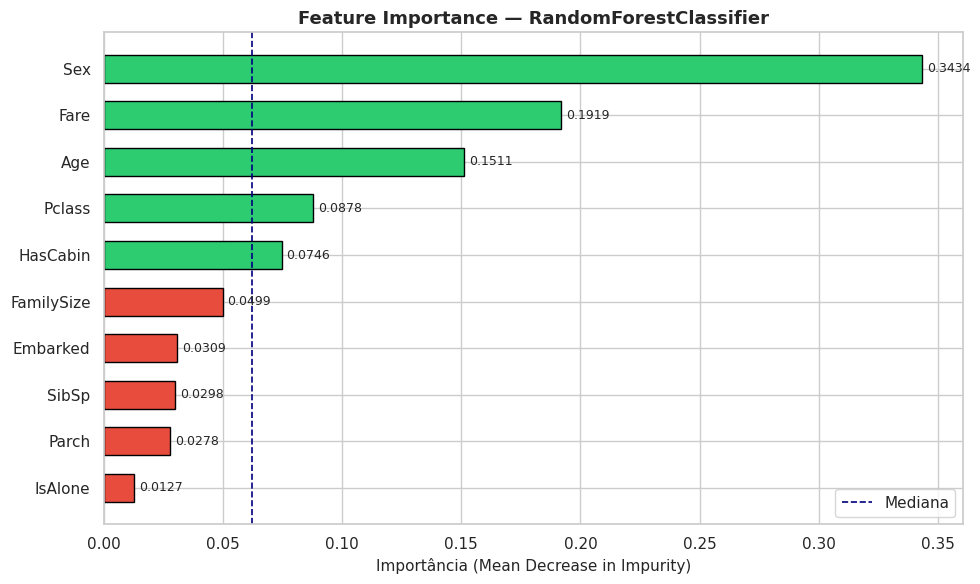


--- Ranking de Importância ---
   Feature  Importance
       Sex    0.343437
      Fare    0.191892
       Age    0.151121
    Pclass    0.087820
  HasCabin    0.074608
FamilySize    0.049855
  Embarked    0.030876
     SibSp    0.029842
     Parch    0.027815
   IsAlone    0.012733


In [65]:
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

colors_imp = ['#2ecc71' if v >= feat_imp_df['Importance'].median() else '#e74c3c'
              for v in feat_imp_df['Importance']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color=colors_imp, edgecolor='black', height=0.6)
ax.set_xlabel('Importância (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Feature Importance — RandomForestClassifier', fontsize=13, fontweight='bold')

for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.axvline(feat_imp_df['Importance'].median(), color='navy',
           linestyle='--', linewidth=1.2, label='Mediana')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Ranking de Importância ---')
print(feat_imp_df.sort_values('Importance', ascending=False).to_string(index=False))

In [66]:
# 6 - EXPLAINABLE AI COM SHAP - SUMMARY PLOT

In [67]:
# Criar explainer SHAP para TreeEnsemble
explainer = shap.TreeExplainer(rf_model)
shap_values_raw = explainer.shap_values(X_test)

# shap_values_raw shape: (n_samples, n_features, n_classes)
sv = np.array(shap_values_raw)
shap_class1 = sv[:, :, 1]           # classe 1 = Sobreviveu
expected_value_class1 = explainer.expected_value[1]

print('SHAP values calculados.')
print(f'Shape dos SHAP values (classe 1): {shap_class1.shape}')
print(f'Expected value (classe 1): {expected_value_class1:.4f}')

SHAP values calculados.
Shape dos SHAP values (classe 1): (179, 10)
Expected value (classe 1): 0.3832


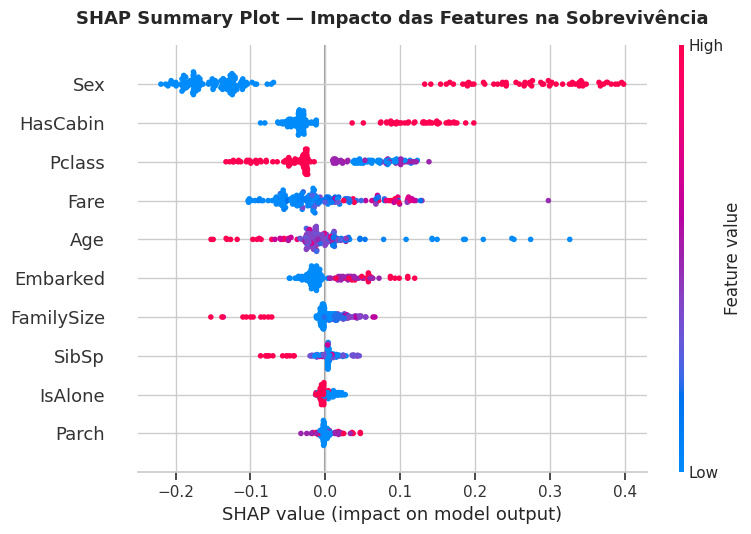

In [68]:
# SHAP Summary Plot (Beeswarm)
plt.figure()
shap.summary_plot(shap_class1, X_test, plot_type='dot',
                  show=False, max_display=10)
plt.title('SHAP Summary Plot — Impacto das Features na Sobrevivência',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

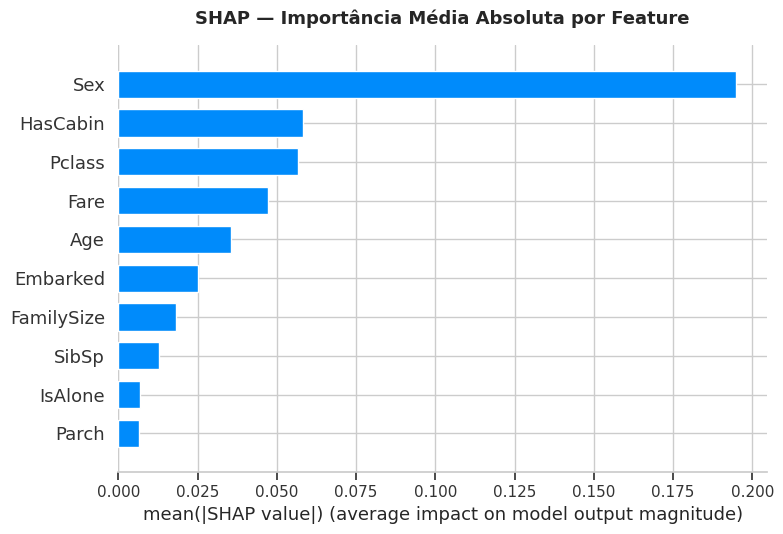

In [69]:
# SHAP Bar Plot (importância média absoluta)
plt.figure()
shap.summary_plot(shap_class1, X_test, plot_type='bar',
                  show=False, max_display=10)
plt.title('SHAP — Importância Média Absoluta por Feature',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [70]:
# 7 - EXPLICAÇÃO DE UMA PREVISÃO INDIVIDUAL

In [71]:
# Selecionar um passageiro do conjunto de teste
# Escolhendo um passageiro que sobreviveu segundo o modelo
test_indices = X_test.index.tolist()

# Encontrar um sobrevivente previsto
sobreviventes_pred = [i for i, p in zip(test_indices, y_pred) if p == 1]
idx_passenger = sobreviventes_pred[0]
passenger_pos = X_test.index.tolist().index(idx_passenger)

passenger = X_test.loc[[idx_passenger]]
real_label = y_test.loc[idx_passenger]
pred_label = rf_model.predict(passenger)[0]
pred_proba = rf_model.predict_proba(passenger)[0]

print(f'=== Passageiro selecionado (índice: {idx_passenger}) ===')
print(passenger.T.rename(columns={idx_passenger: 'Valor'}).to_string())
print()
print(f'Rótulo real       : {real_label} ({"Sobreviveu" if real_label == 1 else "Não Sobreviveu"})')
print(f'Predição do modelo: {pred_label} ({"Sobreviveu" if pred_label == 1 else "Não Sobreviveu"})')
print(f'Probabilidade     : Não sobreviveu = {pred_proba[0]:.3f} | Sobreviveu = {pred_proba[1]:.3f}')

=== Passageiro selecionado (índice: 241) ===
            Valor
Pclass        3.0
Sex           1.0
Age          28.0
SibSp         1.0
Parch         0.0
Fare         15.5
Embarked      2.0
HasCabin      0.0
FamilySize    2.0
IsAlone       0.0

Rótulo real       : 1 (Sobreviveu)
Predição do modelo: 1 (Sobreviveu)
Probabilidade     : Não sobreviveu = 0.424 | Sobreviveu = 0.576


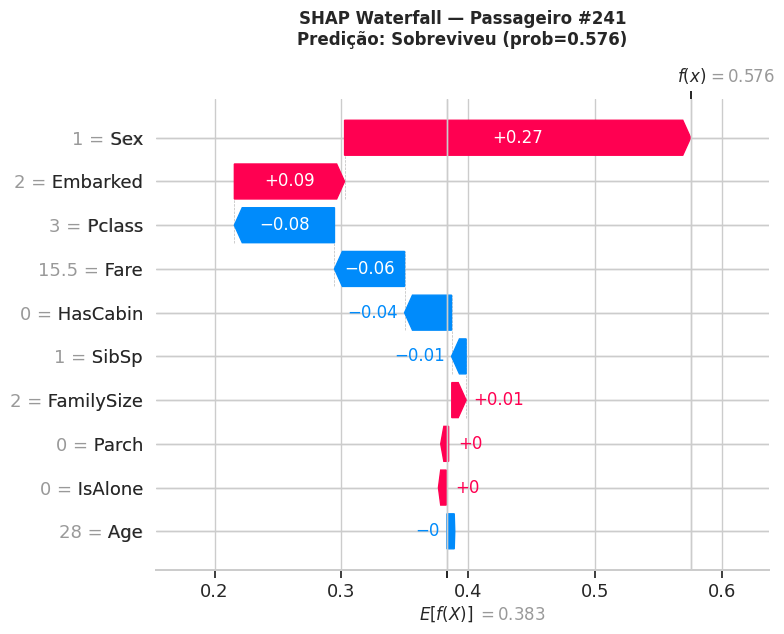

In [72]:
# SHAP Waterfall Plot para o passageiro individual
shap_explanation = shap.Explanation(
    values=shap_class1[passenger_pos],
    base_values=expected_value_class1,
    data=X_test.iloc[passenger_pos].values,
    feature_names=features
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, max_display=10, show=False)
plt.title(f'SHAP Waterfall — Passageiro #{idx_passenger}\n'
          f'Predição: {"Sobreviveu" if pred_label==1 else "Não Sobreviveu"} '
          f'(prob={pred_proba[1]:.3f})',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_waterfall_individual.png', dpi=150, bbox_inches='tight')
plt.show()

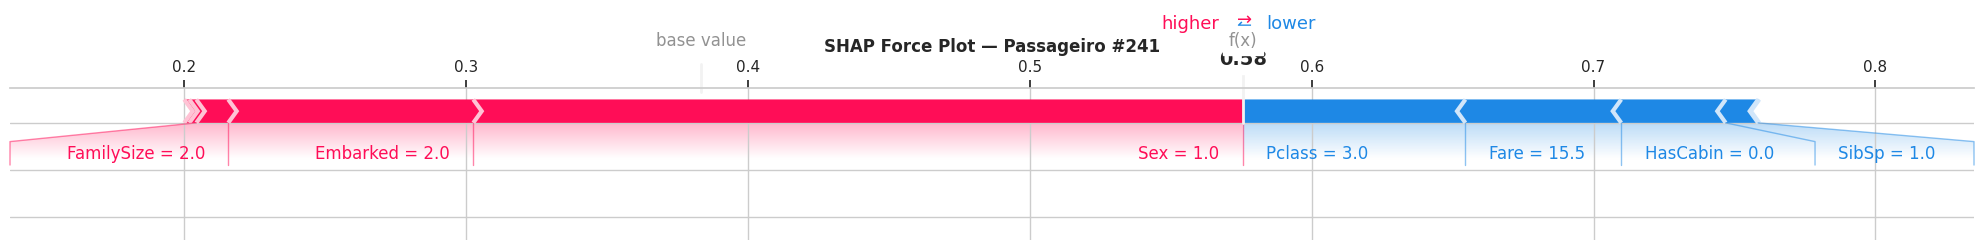

In [73]:
# Force Plot salvo como imagem
shap.initjs()
force = shap.force_plot(
    expected_value_class1,
    shap_class1[passenger_pos],
    X_test.iloc[passenger_pos],
    feature_names=features,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — Passageiro #{idx_passenger}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_force_individual.png', dpi=150, bbox_inches='tight')
plt.show()

In [74]:
# Análise detalhada dos valores SHAP do passageiro
shap_passenger = pd.DataFrame({
    'Feature': features,
    'Valor': X_test.iloc[passenger_pos].values,
    'SHAP Value': shap_class1[passenger_pos]
}).sort_values('SHAP Value', ascending=False)

print(f'=== Análise SHAP do Passageiro #{idx_passenger} ===')
print(f'Valor base (expected value): {expected_value_class1:.4f}')
print(f'Soma SHAP values + base: {expected_value_class1 + shap_class1[passenger_pos].sum():.4f}')
print(f'Probabilidade predita: {pred_proba[1]:.4f}')
print()
print(shap_passenger.to_string(index=False))
print()
print('--- Fatores que AUMENTARAM a probabilidade de sobrevivência ---')
pos = shap_passenger[shap_passenger['SHAP Value'] > 0]
for _, row in pos.iterrows():
    print(f'  ✅ {row["Feature"]:12s} = {row["Valor"]:.2f}  →  SHAP: +{row["SHAP Value"]:.4f}')
print()
print('--- Fatores que REDUZIRAM a probabilidade de sobrevivência ---')
neg = shap_passenger[shap_passenger['SHAP Value'] < 0]
for _, row in neg.iterrows():
    print(f'  ❌ {row["Feature"]:12s} = {row["Valor"]:.2f}  →  SHAP: {row["SHAP Value"]:.4f}')

=== Análise SHAP do Passageiro #241 ===
Valor base (expected value): 0.3832
Soma SHAP values + base: 0.5756
Probabilidade predita: 0.5756

   Feature  Valor  SHAP Value
       Sex    1.0    0.273038
  Embarked    2.0    0.086941
FamilySize    2.0    0.011335
     Parch    0.0    0.002474
   IsAlone    0.0    0.001796
       Age   28.0   -0.000409
     SibSp    1.0   -0.011511
  HasCabin    0.0   -0.037059
      Fare   15.5   -0.055285
    Pclass    3.0   -0.078985

--- Fatores que AUMENTARAM a probabilidade de sobrevivência ---
  ✅ Sex          = 1.00  →  SHAP: +0.2730
  ✅ Embarked     = 2.00  →  SHAP: +0.0869
  ✅ FamilySize   = 2.00  →  SHAP: +0.0113
  ✅ Parch        = 0.00  →  SHAP: +0.0025
  ✅ IsAlone      = 0.00  →  SHAP: +0.0018

--- Fatores que REDUZIRAM a probabilidade de sobrevivência ---
  ❌ Age          = 28.00  →  SHAP: -0.0004
  ❌ SibSp        = 1.00  →  SHAP: -0.0115
  ❌ HasCabin     = 0.00  →  SHAP: -0.0371
  ❌ Fare         = 15.50  →  SHAP: -0.0553
  ❌ Pclass       = 3.0